In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dylanjcastillo/7k-books-with-metadata")

print("Path to dataset files:", path)

Path to dataset files: /home/jittolinux/.cache/kagglehub/datasets/dylanjcastillo/7k-books-with-metadata/versions/3


In [3]:
path

'/home/jittolinux/.cache/kagglehub/datasets/dylanjcastillo/7k-books-with-metadata/versions/3'

In [4]:
import pandas as pd
import os

In [5]:
books = pd.read_csv(os.path.join(path, 'books.csv'))

In [6]:
books.head()

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

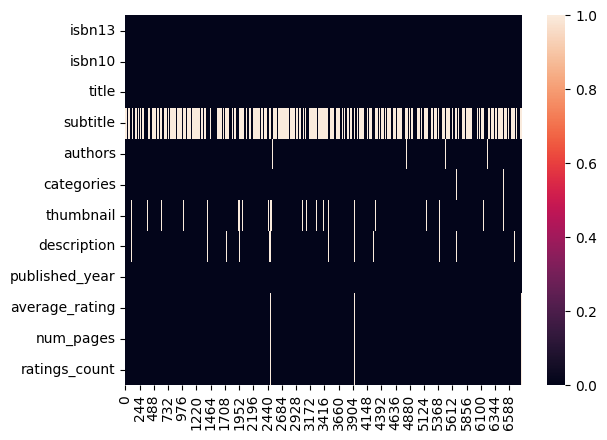

In [8]:
ax = plt.axes()
sns.heatmap(books.isna().transpose(),cbar = True, ax=ax)

plt.show()

In [7]:
book_missing = books[~(books["description"].isna()) &
      ~(books["num_pages"].isna()) &
      ~(books["average_rating"].isna()) &
      ~(books["published_year"].isna())
]

In [10]:
book_missing

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0
...,...,...,...,...,...,...,...,...,...,...,...,...
6803,9788173031014,8173031010,Journey to the East,NaN,Hermann Hesse,Adventure stories,http://books.google.com/books/content?id=rq6JP...,This book tells the tale of a man who goes on ...,2002.0,3.70,175.0,24.0
6804,9788179921623,817992162X,The Monk Who Sold His Ferrari: A Fable About F...,NaN,Robin Sharma,Health & Fitness,http://books.google.com/books/content?id=c_7mf...,"Wisdom to Create a Life of Passion, Purpose, a...",2003.0,3.82,198.0,1568.0
6805,9788185300535,8185300534,I Am that,Talks with Sri Nisargadatta Maharaj,Sri Nisargadatta Maharaj;Sudhakar S. Dikshit,Philosophy,http://books.google.com/books/content?id=Fv_JP...,This collection of the timeless teachings of o...,1999.0,4.51,531.0,104.0
6808,9789027712059,9027712050,The Berlin Phenomenology,NaN,Georg Wilhelm Friedrich Hegel,History,http://books.google.com/books/content?id=Vy7Sk...,Since the three volume edition ofHegel's Philo...,1981.0,0.00,210.0,0.0


In [11]:
book_missing['categories'].value_counts().reset_index().sort_values('count', ascending=False)

,categories,count
0,Fiction,2523
1,Juvenile Fiction,534
2,Biography & Autobiography,391
3,History,258
4,Literary Criticism,164
...,...,...
526,Meditation,1
527,Gay men,1
528,Christian fiction,1
529,"Napoleonic Wars, 1800-1815",1


In [8]:
book_missing['words_in_description'] = book_missing['description'].str.split().str.len()

In [13]:
book_missing['words_in_description']

0       199
1       205
2        14
3        57
4        45
       ... 
6803     63
6804    117
6805    174
6808    245
6809     20
Name: words_in_description, Length: 6507, dtype: int64

<Axes: xlabel='words_in_description', ylabel='Count'>

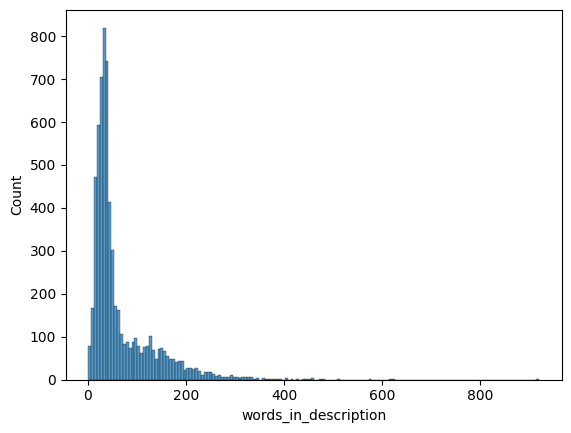

In [14]:
sns.histplot(x='words_in_description', data = book_missing)

In [15]:
book_missing.loc[book_missing['words_in_description'].between(1, 4), 'description']

6                                           Donation.
11                                     Fantasy-roman.
748              Includes bibliographical references.
770                             Bound For Oregon (PB)
775                                No Marketing Blurb
812                                No Marketing Blurb
857                          First published in 1813.
944                         Edited by Maurice Hindle.
953                        DEFOE/ROBINSON CRUSOE (BC)
954                             Edited by John Carey.
962                         ALLEN/GETTING THINGS DONE
1054                            GILBERT/EAT PRAY LOVE
1056    "Graham Greene centennial, 1904-2004"--Cover.
1060                   STEINBECK/GRAPES OF WRATH (BC)
1346                                   Fantasy-roman.
1546                                      Winter 2003
1610                                      Winter 1999
1813                             National bestseller.
1981                        

In [9]:
book_missing_25_words = book_missing[book_missing['words_in_description'] >= 25]

In [ ]:
book_missing_25_words.shape

(5197, 13)

In [10]:
import numpy as np

In [11]:
# Fill NaN in 'subtitle' with empty string before joining
book_missing_25_words['subtitle'] = book_missing_25_words['subtitle'].fillna('')

# Now safely join title and subtitle
book_missing_25_words['title_and_subtitle'] = np.where(
    book_missing_25_words['subtitle'] == '',
    book_missing_25_words['title'],
    book_missing_25_words['title'] + ':' + book_missing_25_words['subtitle']
)   

In [12]:
book_missing_25_words['title_and_subtitle'] 

0                                                  Gilead
1                                    Spider's Web:A Novel
3                                          Rage of angels
4                                          The Four Loves
5                                     The Problem of Pain
                              ...                        
6802                                    Mistaken Identity
6803                                  Journey to the East
6804    The Monk Who Sold His Ferrari: A Fable About F...
6805        I Am that:Talks with Sri Nisargadatta Maharaj
6808                             The Berlin Phenomenology
Name: title_and_subtitle, Length: 5197, dtype: str

In [13]:
book_missing_25_words['tagged_description'] = book_missing_25_words[['isbn13', 'description']].astype(str).agg(" ".join, axis = 1)

In [ ]:
book_missing_25_words['tagged_description']

0       9780002005883 A NOVEL THAT READERS and critics...
1       9780002261982 A new 'Christie for Christmas' -...
3       9780006178736 A memorable, mesmerizing heroine...
4       9780006280897 Lewis' work on the nature of lov...
5       9780006280934 "In The Problem of Pain, C.S. Le...
                              ...                        
6802    9788172235222 On A Train Journey Home To North...
6803    9788173031014 This book tells the tale of a ma...
6804    9788179921623 Wisdom to Create a Life of Passi...
6805    9788185300535 This collection of the timeless ...
6808    9789027712059 Since the three volume edition o...
Name: tagged_description, Length: 5197, dtype: object

In [14]:
(
    book_missing_25_words.drop([
        'subtitle',
        # 'missing_description',
        'words_in_description'
    ], axis = 1)
    .to_csv('./data/books_cleaned.csv', index = False)
)

### Word Embeddings

In [ ]:
# 1. Vector databaset
# 2. Vector Indexing

In [15]:
from langchain_community.document_loaders import TextLoader # Loading data to langchain understanable text
from langchain_text_splitters import CharacterTextSplitter # Breaking down the text to meaningful chunks
from langchain_openai import OpenAIEmbeddings # Converting those into document embeddings
from langchain_chroma import Chroma # Vector database

In [16]:
from dotenv import load_dotenv
import pandas as pd

In [ ]:
load_dotenv('../.env')

True

In [17]:
books = pd.read_csv('./data/books_cleaned.csv')

In [18]:
books['tagged_description']

0       9780002005883 A NOVEL THAT READERS and critics...
1       9780002261982 A new 'Christie for Christmas' -...
2       9780006178736 A memorable, mesmerizing heroine...
3       9780006280897 Lewis' work on the nature of lov...
4       9780006280934 "In The Problem of Pain, C.S. Le...
                              ...                        
5192    9788172235222 On A Train Journey Home To North...
5193    9788173031014 This book tells the tale of a ma...
5194    9788179921623 Wisdom to Create a Life of Passi...
5195    9788185300535 This collection of the timeless ...
5196    9789027712059 Since the three volume edition o...
Name: tagged_description, Length: 5197, dtype: str

In [19]:
books['tagged_description'].to_csv('./data/tagged_descriptions.txt',
                                   sep = '\n',
                                   index = False,
                                   header = False)

In [ ]:
raw_documents = TextLoader('./data/tagged_descriptions.txt').load()
text_splitter = Characte rTextSplitter(chunk_overlap = 0, chunk_size = 0, separator='\n')
documents = text_splitter.split_documents(raw_documents)

SyntaxError: invalid syntax (2721599905.py, line 2)

In [ ]:
books['categories'].value_counts().reset_index().rename(columns={"index": 'category', 'categories': 'count'})

,count,count
0,Fiction,2111
1,Juvenile Fiction,390
2,Biography & Autobiography,311
3,History,207
4,Literary Criticism,124
...,...,...
474,Meditation,1
475,Gay men,1
476,Christian fiction,1
477,"Napoleonic Wars, 1800-1815",1


In [20]:
books[books['categories'] == 'Juvenile Fiction']

,isbn13,isbn10,title,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count,title_and_subtitle,tagged_description
30,9780006646006,000664600X,Ocean Star Express,Mark Haddon;Peter Sutton,Juvenile Fiction,http://books.google.com/books/content?id=I2QZA...,Joe and his parents are enjoying a summer holi...,2002.0,3.50,32.0,1.0,Ocean Star Express,9780006646006 Joe and his parents are enjoying...
79,9780020442608,0020442602,The voyage of the Dawn Treader,Clive Staples Lewis,Juvenile Fiction,http://books.google.com/books/content?id=fDD3C...,"The ""Dawn Treader"" is the first ship Narnia ha...",1970.0,4.09,216.0,2869.0,The voyage of the Dawn Treader,"9780020442608 The ""Dawn Treader"" is the first ..."
85,9780030547744,0030547741,Where the Red Fern Grows,Wilson Rawls,Juvenile Fiction,http://books.google.com/books/content?id=IHpRw...,A young boy living in the Ozarks achieves his ...,2000.0,4.37,288.0,95.0,Where the Red Fern Grows:The Story of Two Dogs...,9780030547744 A young boy living in the Ozarks...
86,9780060000141,0060000147,Poppy's Return,Avi,Juvenile Fiction,http://books.google.com/books/content?id=XbcMJ...,"There's trouble at Gray House, the girlhood ho...",2006.0,3.99,256.0,1086.0,Poppy's Return,"9780060000141 There's trouble at Gray House, t..."
87,9780060001537,0060001534,Diary of a Spider,Doreen Cronin,Juvenile Fiction,http://books.google.com/books/content?id=UWvZo...,This is the diary ... of a spider. But don't b...,2005.0,4.25,40.0,7903.0,Diary of a Spider,9780060001537 This is the diary ... of a spide...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4845,9781590385814,1590385810,Fablehaven,Brandon Mull,Juvenile Fiction,http://books.google.com/books/content?id=tbVIP...,When Kendra and Seth go to stay at their grand...,2006.0,4.09,351.0,111896.0,Fablehaven,9781590385814 When Kendra and Seth go to stay ...
4930,9781596792500,1596792507,Sherlock Holmes and the Case of the Hound of t...,Arthur Conan Doyle;Malvina G. Vogel,Juvenile Fiction,http://books.google.com/books/content?id=EWgWP...,Sherlock Holmes and Dr. Watson travel to the b...,2005.0,4.51,237.0,28.0,Sherlock Holmes and the Case of the Hound of t...,9781596792500 Sherlock Holmes and Dr. Watson t...
4942,9781599900056,159990005X,The Drift House,Dale Peck,Juvenile Fiction,http://books.google.com/books/content?id=kbwPY...,Sent to stay with their uncle in a ship-like h...,2006.0,3.64,437.0,595.0,The Drift House:The First Voyage,9781599900056 Sent to stay with their uncle in...
5010,9781844580514,1844580512,Attack of the Jaguar,M. A. Harvey,Juvenile Fiction,http://books.google.com/books/content?id=3HUdt...,This training manual for operatives of Xtreme ...,2004.0,3.40,125.0,4.0,Attack of the Jaguar,9781844580514 This training manual for operati...


In [21]:
from transformers import pipeline
import torch
# pipe = pipeline('zero-shot-classification', model='facebook/bart-large-mnli')

In [22]:
category_mapping = {'Fiction' : "Fiction",
 'Juvenile Fiction': "Children's Fiction",
 'Biography & Autobiography': "Nonfiction",
 'History': "Nonfiction",
 'Literary Criticism': "Nonfiction",
 'Philosophy': "Nonfiction",
 'Religion': "Nonfiction",
 'Comics & Graphic Novels': "Fiction",
 'Drama': "Fiction",
 'Juvenile Nonfiction': "Children's Nonfiction",
 'Science': "Nonfiction",
 'Poetry': "Fiction"}

books["simple_categories"] = books["categories"].map(category_mapping)

In [23]:
torch.cuda.is_available()

True

In [24]:
from transformers import pipeline
import torch

fiction_categories = ["Fiction", "Nonfiction"]

pipe = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=0 if torch.cuda.is_available() else -1
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [25]:
sequence = books.loc[books['simple_categories'] == 'Fiction', 'description'].reset_index(drop=True)[0]

In [26]:
pipe(sequence, fiction_categories)

/home/jittolinux/miniconda3/envs/tf-nn/lib/python3.11/site-packages/transformers/integrations/sdpa_attention.py:92: UserWarning: Flash Efficient attention on Current AMD GPU is still experimental. Enable it with TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL=1. (Triggered internally at /pytorch/aten/src/ATen/native/transformers/hip/sdp_utils.cpp:320.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
/home/jittolinux/miniconda3/envs/tf-nn/lib/python3.11/site-packages/transformers/integrations/sdpa_attention.py:92: UserWarning: Mem Efficient attention on Current AMD GPU is still experimental. Enable it with TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL=1. (Triggered internally at /pytorch/aten/src/ATen/native/transformers/hip/sdp_utils.cpp:377.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


{'sequence': 'A NOVEL THAT READERS and critics have been eagerly anticipating for over a decade, Gilead is an astonishingly imagined story of remarkable lives. John Ames is a preacher, the son of a preacher and the grandson (both maternal and paternal) of preachers. It’s 1956 in Gilead, Iowa, towards the end of the Reverend Ames’s life, and he is absorbed in recording his family’s story, a legacy for the young son he will never see grow up. Haunted by his grandfather’s presence, John tells of the rift between his grandfather and his father: the elder, an angry visionary who fought for the abolitionist cause, and his son, an ardent pacifist. He is troubled, too, by his prodigal namesake, Jack (John Ames) Boughton, his best friend’s lost son who returns to Gilead searching for forgiveness and redemption. Told in John Ames’s joyous, rambling voice that finds beauty, humour and truth in the smallest of life’s details, Gilead is a song of celebration and acceptance of the best and the worst

In [27]:
import numpy as np
max_index = np.argmax(pipe(sequence, fiction_categories)['scores'])
max_label = pipe(sequence, fiction_categories)['labels'][max_index]

In [28]:
max_label

'Fiction'

In [29]:
def generate_predicitions(sequence, categories):
    predictions = pipe(sequence, categories)
    max_index = np.argmax(predictions['scores'])
    max_label = predictions['labels'][max_index]
    return max_label

In [30]:
from tqdm import tqdm

actual_cat = []
predict_cat = []

for i in tqdm(range(0, 300)):
    sequence = books.loc[books['simple_categories'] == 'Fiction', 'description'].reset_index(drop=True)[i]
    predict_cat += [generate_predicitions(sequence, fiction_categories)]
    actual_cat += ['Fiction']
    
for i in tqdm(range(0, 300)):
    sequence = books.loc[books['simple_categories'] == 'Nonfiction', 'description'].reset_index(drop=True)[i]
    predict_cat += [generate_predicitions(sequence, fiction_categories)]
    actual_cat += ['Nonfiction']    

100%|██████████| 300/300 [00:41<00:00,  7.24it/s]


In [31]:
predictions_df = pd.DataFrame({'actual_categories' : actual_cat, 'predicted_categories' : predict_cat})

In [32]:
predictions_df['correct_predictions'] = np.where(predictions_df['actual_categories'] == predictions_df['predicted_categories'], True, False)

In [37]:
predictions_df['correct_predictions'].sum() / len(predictions_df)

np.float64(0.7783333333333333)

In [38]:
isbns = []
predicted_cats = []

missing_cats = books.loc[books['simple_categories'].isna(), ['isbn13', 'description']].reset_index(drop=True)

In [44]:
predicted_cats = []

In [45]:
for i in tqdm(range(0, len(missing_cats))):
    sequence = missing_cats['description'][i]
    predicted_cats += [generate_predicitions(sequence, fiction_categories)]
    isbns += [missing_cats['isbn13'][i]]

100%|██████████| 1454/1454 [03:06<00:00,  7.81it/s]


In [47]:
missing_predictions_df = pd.DataFrame({'isbn13' : isbns, 'predicted_categories' : predicted_cats})

In [48]:
missing_predictions_df.head()

,isbn13,predicted_categories
0,9780002261982,Fiction
1,9780006280897,Nonfiction
2,9780006280934,Nonfiction
3,9780006380832,Nonfiction
4,9780006470229,Fiction


In [49]:
books = pd.merge(books, missing_predictions_df, on='isbn13', how='left')
books['predicted_categories'] = np.where(books['simple_categories'].isna(), books['predicted_categories'], books['simple_categories'])

In [52]:
books = books.drop(columns = ['predicted_categories'])

In [54]:
books['simple_categories'].unique()

<StringArray>
['Fiction', nan, 'Children's Fiction', 'Nonfiction', 'Children's Nonfiction']
Length: 5, dtype: str

##

### Sentiment Analysis

In [56]:
import pandas as pd
books = pd.read_csv('books_with_categories.csv')

In [57]:
from transformers import pipeline

classifier = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base", return_all_scores=True)
classifier("I love this")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

[{'label': 'joy', 'score': 0.9845667481422424}]

In [58]:
classifier = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base", top_k=None, device=0)


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [59]:
classifier("I love this")

[[{'label': 'joy', 'score': 0.9845667481422424},
  {'label': 'surprise', 'score': 0.004927213303744793},
  {'label': 'sadness', 'score': 0.00453143659979105},
  {'label': 'neutral', 'score': 0.0034753126092255116},
  {'label': 'anger', 'score': 0.0013875334989279509},
  {'label': 'disgust', 'score': 0.0007134054321795702},
  {'label': 'fear', 'score': 0.00039849214954301715}]]

In [60]:
books['description'][0]

'A NOVEL THAT READERS and critics have been eagerly anticipating for over a decade, Gilead is an astonishingly imagined story of remarkable lives. John Ames is a preacher, the son of a preacher and the grandson (both maternal and paternal) of preachers. It’s 1956 in Gilead, Iowa, towards the end of the Reverend Ames’s life, and he is absorbed in recording his family’s story, a legacy for the young son he will never see grow up. Haunted by his grandfather’s presence, John tells of the rift between his grandfather and his father: the elder, an angry visionary who fought for the abolitionist cause, and his son, an ardent pacifist. He is troubled, too, by his prodigal namesake, Jack (John Ames) Boughton, his best friend’s lost son who returns to Gilead searching for forgiveness and redemption. Told in John Ames’s joyous, rambling voice that finds beauty, humour and truth in the smallest of life’s details, Gilead is a song of celebration and acceptance of the best and the worst the world ha

In [63]:
response = classifier(books['description'][0])

In [67]:
response[0][0]['score']

0.6548413038253784

In [68]:
classifier(books['description'][0].split("."))

[[{'label': 'surprise', 'score': 0.7296029925346375},
  {'label': 'neutral', 'score': 0.14038552343845367},
  {'label': 'fear', 'score': 0.06816209852695465},
  {'label': 'joy', 'score': 0.047942452132701874},
  {'label': 'anger', 'score': 0.00915633887052536},
  {'label': 'disgust', 'score': 0.0026284761261194944},
  {'label': 'sadness', 'score': 0.0021221612114459276}],
 [{'label': 'neutral', 'score': 0.4493700861930847},
  {'label': 'disgust', 'score': 0.27359244227409363},
  {'label': 'joy', 'score': 0.109082892537117},
  {'label': 'sadness', 'score': 0.09362704306840897},
  {'label': 'anger', 'score': 0.040478359907865524},
  {'label': 'surprise', 'score': 0.026970136910676956},
  {'label': 'fear', 'score': 0.006879070773720741}],
 [{'label': 'neutral', 'score': 0.6462167501449585},
  {'label': 'sadness', 'score': 0.24273276329040527},
  {'label': 'disgust', 'score': 0.04342261329293251},
  {'label': 'surprise', 'score': 0.028300462290644646},
  {'label': 'joy', 'score': 0.0142114

In [69]:
setences = books['description'][0].split('.')

In [70]:
predictions = classifier(setences)

In [71]:
predictions[0]

[{'label': 'surprise', 'score': 0.7296029925346375},
 {'label': 'neutral', 'score': 0.14038552343845367},
 {'label': 'fear', 'score': 0.06816209852695465},
 {'label': 'joy', 'score': 0.047942452132701874},
 {'label': 'anger', 'score': 0.00915633887052536},
 {'label': 'disgust', 'score': 0.0026284761261194944},
 {'label': 'sadness', 'score': 0.0021221612114459276}]

In [72]:
emotion_labels = ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'neutral']

isbn = []

emotion_scores = {label: [] for label in emotion_labels}

In [73]:
emotion_scores

{'anger': [],
 'disgust': [],
 'fear': [],
 'joy': [],
 'sadness': [],
 'surprise': [],
 'neutral': []}

In [74]:
def calculate_max_emotion_scores(predictions):
    per_emotion_scores = {label: [] for label in emotion_scores}

    for predicition in predictions:
        sorted_predictions = sorted(predicition, key = lambda x: x['label'])
        for index, label in enumerate(sorted_predictions):
            per_emotion_scores[label].append(sorted_predictions[index]['scores'])
    
    return {label: np.max(scores) for label, scores in per_emotion_scores.items()}

In [ ]:
for i in range(10):
    isbn.append(books['isbn13'][i])
    sentences = books['description'][i].split('.')
    predictions = classifier(sentences)
    max_prediction = calculate_max_emotion_scores(predictions)    
